# EDA: Реєстр платників ПДВ України

**Опис:** первинний огляд та підготовка даних реєстру платників ПДВ (Open Data).

**Мета:** перевірити структуру, якість даних і підготувати базову візуалізацію для подальшого аналізу.

## Імпорти
Стандартні бібліотеки для аналізу та візуалізації.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.config import (
    DATA_FILE, CSV_SEP, CSV_ENCODING, CSV_ON_BAD_LINES,
    DATE_FORMAT, PLOT_STYLE, PANDAS_MAX_COLUMNS,
    ANALYSIS_START_YEAR, ECONOMIC_EVENT_YEAR,
)

from src.analysis import (
    analyze_seasonality,
    analyze_legal_forms,
    analyze_economic_impact
)

## Конфігурація
Налаштування відображення та стилю графіків.

In [2]:
pd.set_option("display.max_columns", PANDAS_MAX_COLUMNS)
plt.style.use(PLOT_STYLE)

## Завантаження даних
Читаємо CSV з обробкою кодування та помилкових рядків.

In [3]:
df = pd.read_csv(
    DATA_FILE,
    sep=CSV_SEP,
    encoding=CSV_ENCODING,
    on_bad_lines=CSV_ON_BAD_LINES,
)

df["dat_term"] = df["dat_term"].replace("null", pd.NA)
df["dat_reestr"] = pd.to_datetime(df["dat_reestr"], format=DATE_FORMAT, errors="coerce")

## Базовий огляд
Швидко перевіряємо перші рядки, типи полів та пропуски.

In [4]:
print("Data head:")
df.head()

Data head:


,name,kod_pdv,dat_reestr,dat_term
0,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВІДПОВІДАЛЬНІСТЮ ЗОНТА-...,356383613199,2011-06-01,NaN
1,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВІДПОВІДАЛЬНІСТЮ `ЗОЛОЧ...,337643613199,2005-11-24,NaN
2,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВIДПОВIДАЛЬНIСТЮ ЛІВС А...,342753223040,2006-12-22,NaN
3,"ПРИВАТНЕ ПIДПРИЄМСТВО ЕНЕРГО-ІНВЕСТ""""",320265706190,2002-09-26,NaN
4,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВIДПОВIДАЛЬНIСТЮ СК ТРЕ...,372635220232,2010-10-05,NaN


In [5]:
print("Data info:")
df.info()

print("\nData missing values:")
df.isnull().sum()

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 281074 entries, 0 to 281073
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   name        281074 non-null  str           
 1   kod_pdv     281074 non-null  str           
 2   dat_reestr  281021 non-null  datetime64[us]
 3   dat_term    555 non-null     str           
dtypes: datetime64[us](1), str(3)
memory usage: 8.6 MB

Data missing values:


name               0
kod_pdv            0
dat_reestr        53
dat_term      280519
dtype: int64

## Візуалізація
Приклад: кількість реєстрацій за роками.

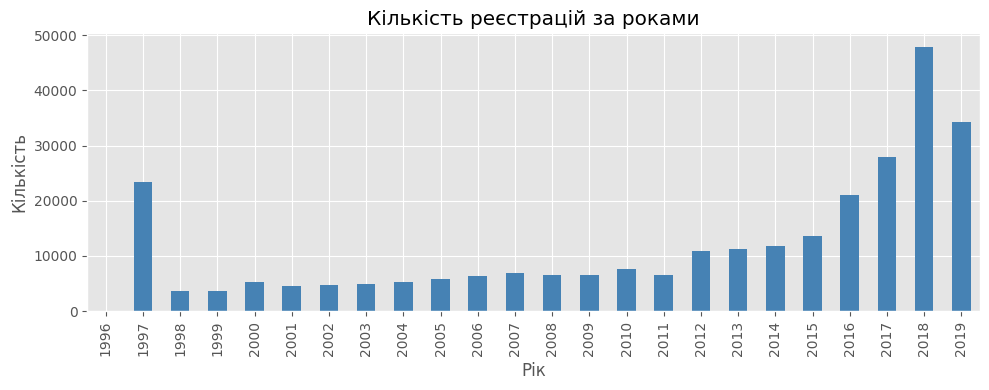

In [6]:
registrations_by_year = (
    df.dropna(subset=["dat_reestr"])
    .assign(year=lambda x: x["dat_reestr"].dt.year)
    .groupby("year")
    .size()
    .sort_index()
 )

plt.figure(figsize=(10, 4))
registrations_by_year.plot(kind="bar", color="steelblue")
plt.title("Кiлькiсть реєстрацiй за роками")
plt.xlabel("Рiк")
plt.ylabel("Кiлькiсть")
plt.tight_layout()
plt.show()

## Гіпотеза 1: Сезонність реєстрацій

**Припущення:** Реєстрація нових платників ПДВ має чітко виражену сезонність із піками на початку кожного кварталу (січень, квітень, липень, жовтень).

Розподіл реєстрацій за місяцями:
month
1     24822
2     17666
3     20628
4     26494
5     20334
6     20134
7     38390
8     21672
9     24788
10    25360
11    20197
12    20536
dtype: int64

Розподіл реєстрацій за кварталами:
quarter
1    63116
2    66962
3    84850
4    66093
dtype: int64


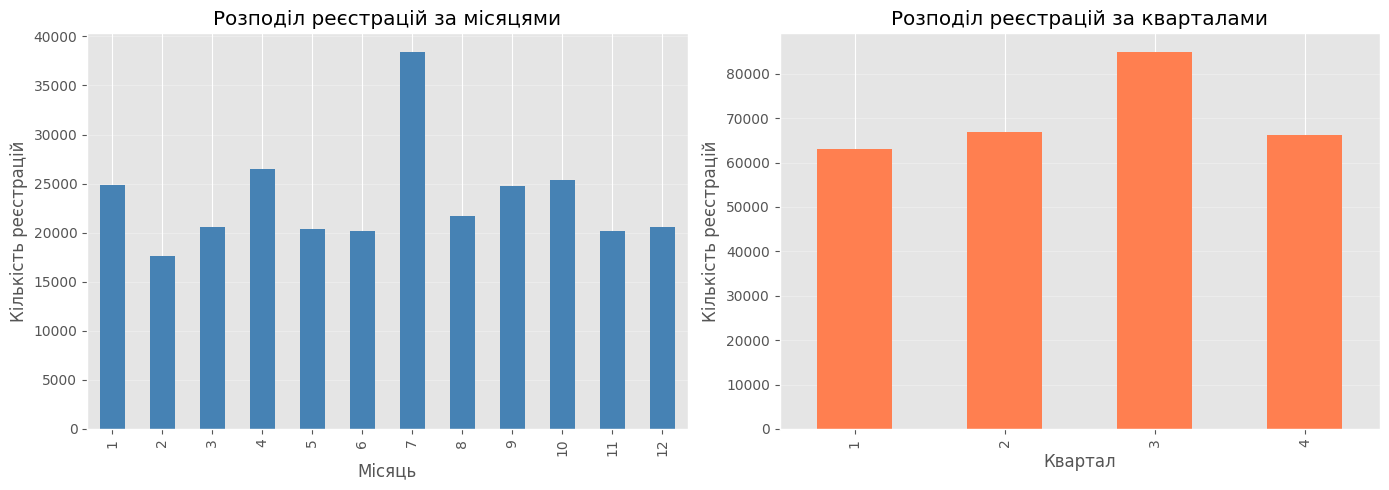


✓ Аналіз гіпотези:
  Піковий місяць: 7 (38,390 реєстрацій)
  Найменш активний місяць: 2 (17,666 реєстрацій)
  Очікування: піки у місяцях 1, 4, 7, 10 (початок кварталів)


In [ ]:
results = analyze_seasonality(df)

print("Розподіл реєстрацій за місяцями:")
print(results["registrations_by_month"])
print("\nРозподіл реєстрацій за кварталами:")
print(results["registrations_by_quarter"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results["registrations_by_month"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Розподіл реєстрацій за місяцями")
axes[0].set_xlabel("Місяць")
axes[0].set_ylabel("Кількість реєстрацій")
axes[0].set_xticklabels(range(1, 13))
axes[0].grid(True, alpha=0.3, axis="y")

results["registrations_by_quarter"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Розподіл реєстрацій за кварталами")
axes[1].set_xlabel("Квартал")
axes[1].set_ylabel("Кількість реєстрацій")
axes[1].set_xticklabels(range(1, 5))
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n✓ Аналіз гіпотези:")
print(f"  Піковий місяць: {results['peak_month']} ({results['peak_count']:,} реєстрацій)")
print(f"  Найменш активний місяць: {results['low_month']} ({results['low_count']:,} реєстрацій)")
print("  Очікування: піки у місяцях 1, 4, 7, 10 (початок кварталів)")

## Гіпотеза 2: Зміна популярності організаційно-правових форм

**Припущення:** Популярність форми "Приватне підприємство" (ПП) серед нових платників ПДВ катастрофічно знизилася на користь "Товариств з обмеженою відповідальністю" (ТОВ) після 2010 року.

Розподіл форм за роками та періодами:

До 2010 року:
form
Інше    22140
АТ       3580
ЗАТ        80
ПП      15155
ТОВ     47089
dtype: int64
Всього: 88044

Від 2010 року:
form
Інше     25926
АТ         293
ЗАТ         11
ПП       11461
ТОВ     155286
dtype: int64
Всього: 192977


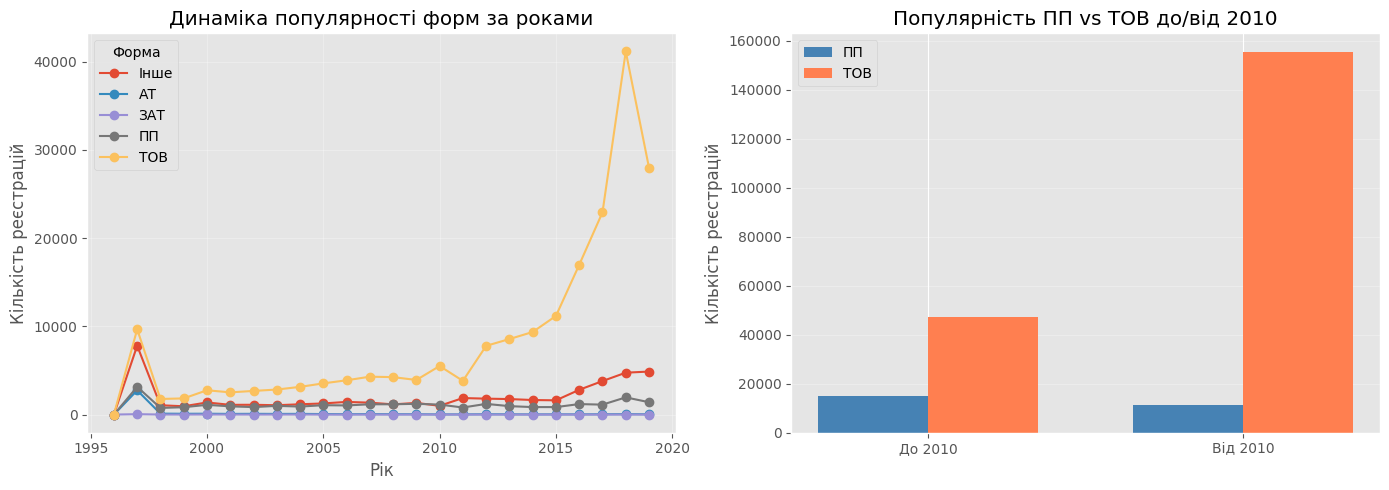


Аналіз гіпотези:
  ПП: 15,155 → 11,461 (-24.4%)
  ТОВ: 47,089 → 155,286 (+229.8%)
Гіпотеза підтверджується!


In [8]:
results = analyze_legal_forms(df, event_year=2010)

print("Розподіл форм за роками та періодами:")
print("\nДо 2010 року:")
print(results["before_event"])
print(f"Всього: {results['before_event'].sum()}")

print(f"\nВід 2010 року:")
print(results["after_event"])
print(f"Всього: {results['after_event'].sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results["forms_by_year"].plot(ax=axes[0], marker="o")
axes[0].set_title("Динаміка популярності форм за роками")
axes[0].set_xlabel("Рік")
axes[0].set_ylabel("Кількість реєстрацій")
axes[0].legend(title="Форма", loc="best")
axes[0].grid(True, alpha=0.3)

periods = ["До 2010", "Від 2010"]
pp_values = [results["pp_before"], results["pp_after"]]
tov_values = [results["tov_before"], results["tov_after"]]

x = range(len(periods))
width = 0.35

axes[1].bar([i - width/2 for i in x], pp_values, width, label="ПП", color="steelblue")
axes[1].bar([i + width/2 for i in x], tov_values, width, label="ТОВ", color="coral")
axes[1].set_title("Популярність ПП vs ТОВ до/від 2010")
axes[1].set_ylabel("Кількість реєстрацій")
axes[1].set_xticks(x)
axes[1].set_xticklabels(periods)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nАналіз гіпотези:")
print(f"  ПП: {results['pp_before']:,} → {results['pp_after']:,} ({results['pp_change_pct']:+.1f}%)")
print(f"  ТОВ: {results['tov_before']:,} → {results['tov_after']:,} ({results['tov_change_pct']:+.1f}%)")
if results["pp_declined"] and results["tov_increased"]:
    print("Гіпотеза підтверджується!")
else:
    print("Гіпотеза не повністю підтверджується")

## Гіпотеза 3: Вплив економічних подій на реєстрацію

**Припущення:** Кількість нових реєстрацій платників ПДВ суттєво зросла після 2014 року порівняно з періодом 2010–2013 років.

Порівняння періодів:

2010-2013 роки:
  Всього реєстрацій: 36,319
  Років у періоді: 4
  Середньо на рік: 9,080

від 2014:
  Всього реєстрацій: 156,658
  Років у періоді: 6
  Середньо на рік: 26,110

Зміна середньої кількості: +187.6%


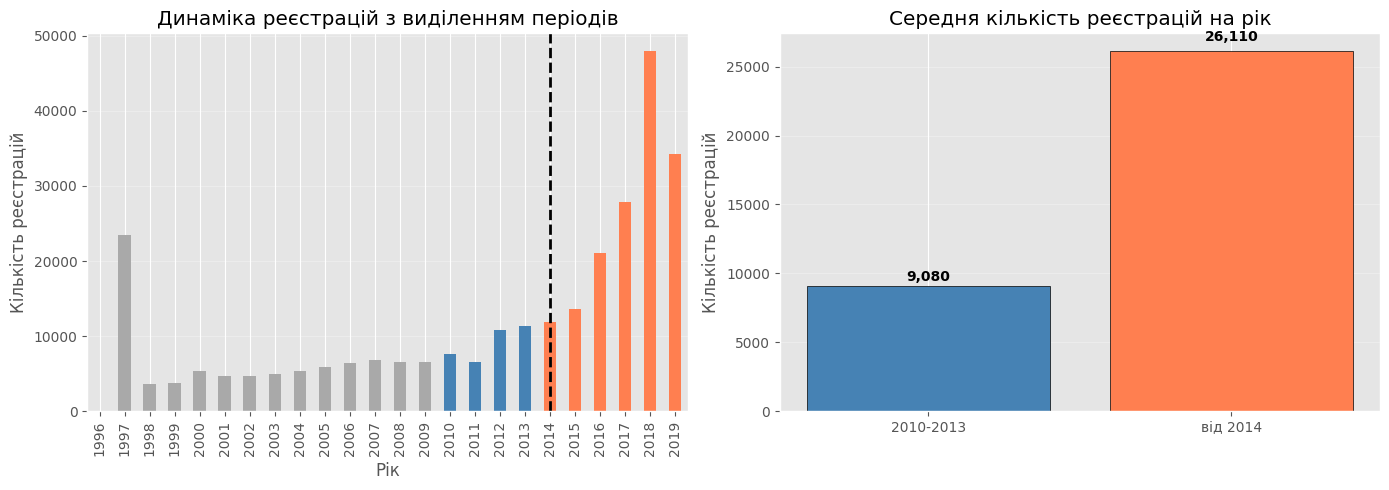


✓ Аналіз гіпотези:
  Гіпотеза підтверджується: реєстрації зросли на 187.6%


In [9]:
results = analyze_economic_impact(df)

print("Порівняння періодів:")
print(f"\n{results['before_event']['period']} роки:")
print(f"  Всього реєстрацій: {results['before_event']['total']:,}")
print(f"  Років у періоді: {results['before_event']['years']}")
print(f"  Середньо на рік: {results['before_event']['avg_per_year']:,.0f}")

print(f"\n{results['after_event']['period']}:")
print(f"  Всього реєстрацій: {results['after_event']['total']:,}")
print(f"  Років у періоді: {results['after_event']['years']}")
print(f"  Середньо на рік: {results['after_event']['avg_per_year']:,.0f}")

print(f"\nЗміна середньої кількості: {results['change_percent']:+.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years_list = results["registrations_per_year"].index.tolist()
colors_bars = [
    'steelblue' if ANALYSIS_START_YEAR <= year < ECONOMIC_EVENT_YEAR
    else 'coral' if year >= ECONOMIC_EVENT_YEAR
    else 'darkgray'
    for year in years_list
]

results["registrations_per_year"].plot(kind="bar", ax=axes[0], color=colors_bars)

if ECONOMIC_EVENT_YEAR in years_list:
    idx_event = years_list.index(ECONOMIC_EVENT_YEAR)
    axes[0].axvline(x=idx_event, color="black", linestyle="--", linewidth=2)

axes[0].set_title("Динаміка реєстрацій з виділенням періодів")
axes[0].set_xlabel("Рік")
axes[0].set_ylabel("Кількість реєстрацій")
axes[0].grid(True, alpha=0.3, axis="y")

periods = [results['before_event']['period'], results['after_event']['period']]
averages = [
    results['before_event']['avg_per_year'],
    results['after_event']['avg_per_year']
]
colors = ["steelblue", "coral"]

axes[1].bar(periods, averages, color=colors, edgecolor="black")
axes[1].set_title("Середня кількість реєстрацій на рік")
axes[1].set_ylabel("Кількість реєстрацій")
axes[1].grid(True, alpha=0.3, axis="y")

for i, v in enumerate(averages):
    axes[1].text(i, v + v*0.02, f"{v:,.0f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

print("\n✓ Аналіз гіпотези:")
if results["hypothesis_confirmed"]:
    print(f"  Гіпотеза підтверджується: реєстрації зросли на {results['change_percent']:.1f}%")
else:
    print(f"  Гіпотеза не підтверджується: зміна {results['change_percent']:.1f}%")